<a href="https://colab.research.google.com/github/Bhanu-Jakka/ML_Project/blob/main/Model_Selection_%26_Training_IPL_MatchPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.model_selection import train_test_split

model_df = pd.read_csv('model_ready_data.csv')

X = model_df.drop(columns=['team1_win'])
y = model_df['team1_win']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_val.to_csv('y_val.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

Train: (762, 19)  Val: (164, 19)  Test: (164, 19)


In [ ]:
## Imports
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)

In [ ]:
## Load the train/val splits
X_train = pd.read_csv('X_train.csv')
X_val = pd.read_csv('X_val.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_val = pd.read_csv('y_val.csv').squeeze()

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

X_train: (762, 19)
X_val: (164, 19)


In [ ]:
## Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [ ]:
## Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression trained.")
print("Train accuracy:", log_reg.score(X_train_scaled, y_train))
print("Val accuracy:", log_reg.score(X_val_scaled, y_val))

Logistic Regression trained.
Train accuracy: 0.5708661417322834
Val accuracy: 0.5121951219512195


In [ ]:
## Train Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, y_train)  # tree models don't need scaled features

print("Random Forest trained.")
print("Train accuracy:", rf.score(X_train, y_train))
print("Val accuracy:", rf.score(X_val, y_val))

Random Forest trained.
Train accuracy: 0.979002624671916
Val accuracy: 0.524390243902439


In [ ]:
## Quick side-by-side comparison on validation set
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Train Accuracy': [log_reg.score(X_train_scaled, y_train), rf.score(X_train, y_train)],
    'Val Accuracy': [log_reg.score(X_val_scaled, y_val), rf.score(X_val, y_val)]
})
print(results)

                 Model  Train Accuracy  Val Accuracy
0  Logistic Regression        0.570866      0.512195
1        Random Forest        0.979003      0.524390


In [ ]:
## Save trained models
import joblib

joblib.dump(log_reg, 'logistic_regression_model.pkl')
joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Models saved: logistic_regression_model.pkl, random_forest_model.pkl, scaler.pkl")

Models saved: logistic_regression_model.pkl, random_forest_model.pkl, scaler.pkl


In [11]:
## Step 8 (continued) — Retrain with Reduced Feature Set

In [12]:
model_df = pd.read_csv('model_ready_data.csv')

drop_cols = ['team1_rest_days', 'team2_rest_days', 'team1_win_streak', 'team2_win_streak']
model_df_reduced = model_df.drop(columns=drop_cols)

X_reduced = model_df_reduced.drop(columns=['team1_win'])
y_reduced = model_df_reduced['team1_win']

print("Reduced feature set:", X_reduced.columns.tolist())
print("Shape:", X_reduced.shape)

Reduced feature set: ['team1_form', 'team2_form', 'h2h_team1_win_ratio', 'team1_home', 'team2_home', 'toss_won_by_team1', 'toss_decision_bat', 'team1_venue_form', 'team2_venue_form', 'team1_avg_runs_scored', 'team2_avg_runs_scored', 'team1_avg_runs_conceded', 'team2_avg_runs_conceded', 'team1_avg_wickets_taken', 'team2_avg_wickets_taken']
Shape: (1090, 15)


In [13]:
from sklearn.model_selection import train_test_split

X_temp2, X_test2, y_temp2, y_test2 = train_test_split(
    X_reduced, y_reduced, test_size=0.15, random_state=42, stratify=y_reduced
)
X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_temp2, y_temp2, test_size=0.1765, random_state=42, stratify=y_temp2
)

print("Train:", X_train2.shape, " Val:", X_val2.shape, " Test:", X_test2.shape)

Train: (762, 15)  Val: (164, 15)  Test: (164, 15)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

log_reg2 = LogisticRegression(max_iter=1000, random_state=42)
log_reg2.fit(X_train2_scaled, y_train2)

rf2 = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf2.fit(X_train2, y_train2)

print("Retrained on reduced feature set.")

Retrained on reduced feature set.


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred_lr2 = log_reg2.predict(X_test2_scaled)
y_prob_lr2 = log_reg2.predict_proba(X_test2_scaled)[:, 1]
y_pred_rf2 = rf2.predict(X_test2)
y_prob_rf2 = rf2.predict_proba(X_test2)[:, 1]

def get_metrics(y_true, y_pred, y_prob, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

results_reduced = pd.DataFrame([
    get_metrics(y_test2, y_pred_lr2, y_prob_lr2, 'Logistic Regression (reduced)'),
    get_metrics(y_test2, y_pred_rf2, y_prob_rf2, 'Random Forest (reduced)')
])

print(results_reduced)

                           Model  Accuracy  Precision    Recall  F1 Score  \
0  Logistic Regression (reduced)  0.536585   0.546512  0.559524  0.552941   
1        Random Forest (reduced)  0.530488   0.540230  0.559524  0.549708   

    ROC-AUC  
0  0.522321  
1  0.545685  


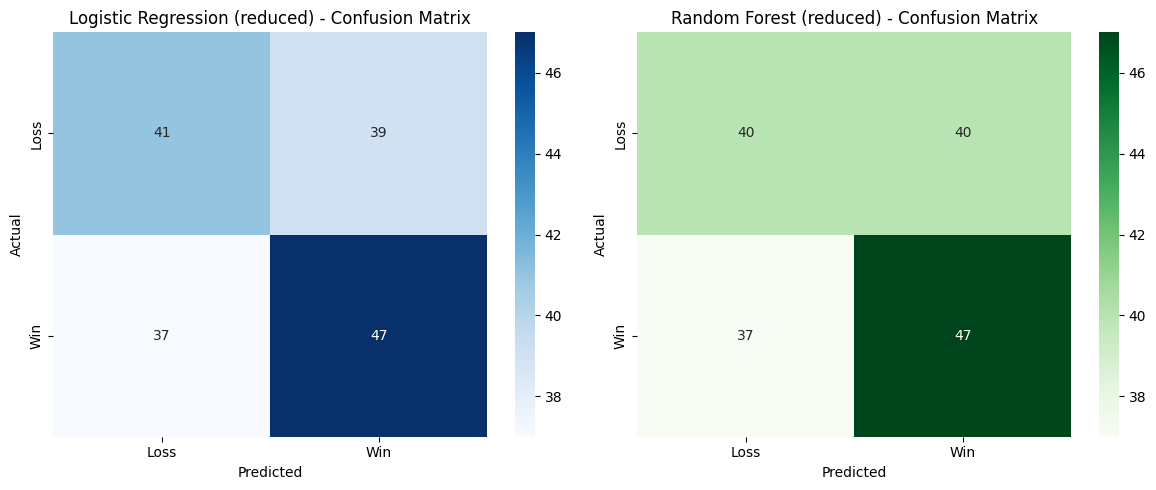

In [16]:
## Confusion matrices
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr2 = confusion_matrix(y_test2, y_pred_lr2)
sns.heatmap(cm_lr2, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Loss','Win'], yticklabels=['Loss','Win'])
axes[0].set_title('Logistic Regression (reduced) - Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

cm_rf2 = confusion_matrix(y_test2, y_pred_rf2)
sns.heatmap(cm_rf2, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Loss','Win'], yticklabels=['Loss','Win'])
axes[1].set_title('Random Forest (reduced) - Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [17]:
## Classification reports
print("=== Logistic Regression (reduced) ===")
print(classification_report(y_test2, y_pred_lr2, target_names=['Loss','Win']))

print("\n=== Random Forest (reduced) ===")
print(classification_report(y_test2, y_pred_rf2, target_names=['Loss','Win']))

=== Logistic Regression (reduced) ===
              precision    recall  f1-score   support

        Loss       0.53      0.51      0.52        80
         Win       0.55      0.56      0.55        84

    accuracy                           0.54       164
   macro avg       0.54      0.54      0.54       164
weighted avg       0.54      0.54      0.54       164


=== Random Forest (reduced) ===
              precision    recall  f1-score   support

        Loss       0.52      0.50      0.51        80
         Win       0.54      0.56      0.55        84

    accuracy                           0.53       164
   macro avg       0.53      0.53      0.53       164
weighted avg       0.53      0.53      0.53       164



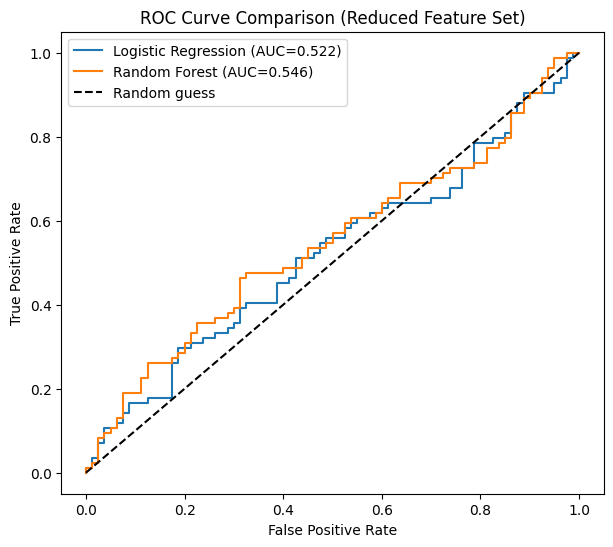

In [18]:
## ROC curves
from sklearn.metrics import roc_curve, roc_auc_score

fpr_lr2, tpr_lr2, _ = roc_curve(y_test2, y_prob_lr2)
fpr_rf2, tpr_rf2, _ = roc_curve(y_test2, y_prob_rf2)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr2, tpr_lr2, label=f'Logistic Regression (AUC={roc_auc_score(y_test2, y_prob_lr2):.3f})')
plt.plot(fpr_rf2, tpr_rf2, label=f'Random Forest (AUC={roc_auc_score(y_test2, y_prob_rf2):.3f})')
plt.plot([0,1],[0,1],'k--', label='Random guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Reduced Feature Set)')
plt.legend()
plt.show()

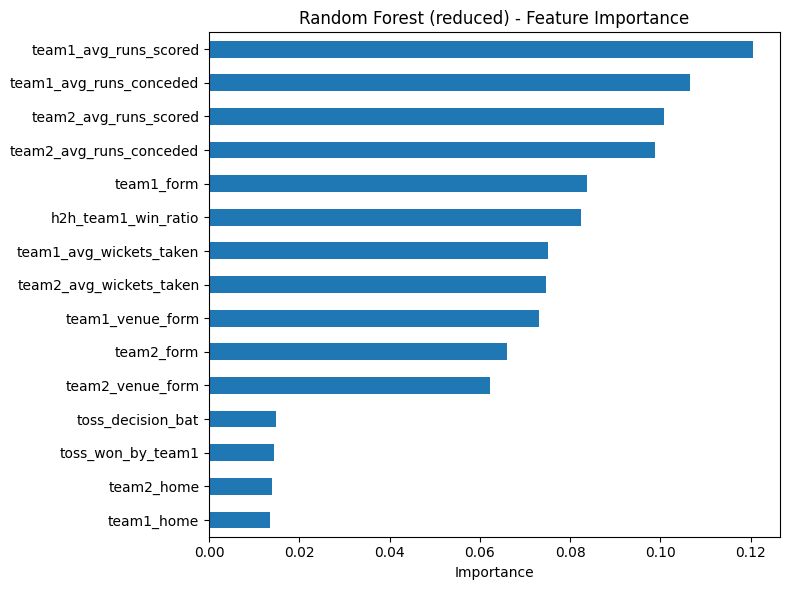

team1_avg_runs_scored      0.120459
team1_avg_runs_conceded    0.106452
team2_avg_runs_scored      0.100715
team2_avg_runs_conceded    0.098754
team1_form                 0.083673
h2h_team1_win_ratio        0.082378
team1_avg_wickets_taken    0.074978
team2_avg_wickets_taken    0.074708
team1_venue_form           0.073002
team2_form                 0.065994
team2_venue_form           0.062219
toss_decision_bat          0.014875
toss_won_by_team1          0.014434
team2_home                 0.013842
team1_home                 0.013517
dtype: float64


In [19]:
## Feature importance(Random Forest)
importances2 = pd.Series(rf2.feature_importances_, index=X_reduced.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances2.plot(kind='barh')
plt.title('Random Forest (reduced) - Feature Importance')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importances2)

In [20]:
## Save the final models
import joblib

joblib.dump(log_reg2, 'logistic_regression_model_final.pkl')
joblib.dump(rf2, 'random_forest_model_final.pkl')
joblib.dump(scaler2, 'scaler_final.pkl')

print("Final models saved.")

Final models saved.
